<a href="https://colab.research.google.com/github/Isaiah-Essien/drug_review_sentiment_analysis/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Drug Review Sentiment Analysis

This project aimed to analyze drug reviews and develop a sentiment classification model to predict the sentiment of a given drug review and assign an automatic rating score based on its content.

## Exploratory Data Analysis (EDA) Summary
The dataset was analyzed to understand its structure, distribution, and key characteristics. The analysis included:

- Class Distribution: A bar plot was used to visualize the distribution of positive, neutral, and negative sentiment classes. The dataset showed a class imbalance, with more positive reviews.
- Review Lengths: Word and sentence counts were analyzed, showing that most - reviews contained between 50 and 200 words.
- Term Frequency Analysis: The most frequently used words and common n-grams were identified using bar plots and WordClouds.
- Outliers & Missing Values: The most frequently reviewed drugs were identified, missing values were handled, and unique rating values were examined.
These insights guided data preprocessing and model development.

## Model Development & Training
Three different models were trained and evaluated for sentiment classification:

1. Naïve Bayes Model: A traditional text classification approach using TF-IDF and Multinomial Naïve Bayes.
2. LSTM Model: A deep learning approach leveraging an embedding layer, LSTM layers, and dropout for sentiment analysis.
3. Transformer Model: A more advanced neural network model utilizing transformer-based architectures like DistilBERT for contextual understanding of drug reviews.
Each model was assessed based on performance metrics, and their effectiveness was compared.

## Prediction & Deployment
A function was implemented to predict sentiment based on input drug reviews.
The model was enhanced to generate a rating score based on the predicted sentiment rather than relying on user-provided ratings.
The trained models and preprocessing components were saved for future deployment.

# Imports

In [ ]:
from requests import get
from io import StringIO
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
import pickle

# Loading the Data
The datasets for this project are public available on [Kaggle](https://www.kaggle.com/datasets/mohamedabdelwahabali/drugreview). To make it easier to load the data into this notebook, we hosted the datasets on Google Drive and generated download urls which we will use to download the datasets.

In [ ]:
dataset_urls = {
    'test': 'https://drive.google.com/uc?export=download&id=1Bi-gQ7QXYZ_kXLl4XkDis26N1-5265s5',
    'train': 'https://drive.google.com/uc?export=download&id=1UBg0hSa3bLUOs5AwjIdX9lnWWaLdNeiX',
    'val': 'https://drive.google.com/uc?export=download&id=1DcBRSmjyCMtR2vk2dLWn0_lDf2X3JhBq'
}

In [ ]:
def load_dataset(url):
  """ Loads a csv dataset from Google Drive
  Args:
    url (string): The url of the dataset
  Returns:
    (pandas.DataFrame) A pandas dataframe
    containing the dataset
  """
  response = get(url, allow_redirects=True)

  if response.status_code == 200:
    csv_io = StringIO(response.text)
    return pd.read_csv(csv_io)
  else:
    raise Exception(f"Failed to load dataset. HTTP Status Code: {response.status_code}")

In [ ]:
train = load_dataset(dataset_urls['train'])
test = load_dataset(dataset_urls['test'])
val = load_dataset(dataset_urls['val'])

In [ ]:
train.shape

(110811, 9)

In [ ]:
test.shape

(46108, 9)

In [ ]:
val.shape

(27703, 9)

# Exploratory Data Analysis

In this section, we are going to explore the data to prepare it for exploratory analysis and training.

In [ ]:
# Combine the datasets for Exploratory Data Analysis
eda_dataset = pd.concat([train, test, val])

## Language Analysis
In this section, we are going to analyse the language used by reviewers. Specifically, we going to det
ermine the following:
1. Vocabulary
2. Term Frequency Analysis
3. Most Frequently Occuring n-grams.
4. Class balance/Sentiment Distribution


### Vocabulary

We performed vocabulary analysis to see the range of words used and it showed that in total, reviewers used 42,053 words. However, there are also common misspellings in the reviews which might need correction before feeding them into the network.

In [ ]:
ENGLISH_STOP_WORDS_LIST = ["i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", "yourself", "yourselves", "he", "him", "his", "himself", "she", "her", "hers", "herself", "it", "its", "itself", "they", "them", "their", "theirs", "themselves", "what", "which", "who", "whom", "this", "that", "these", "those", "am", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had", "having", "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if", "or", "because", "as", "until", "while", "of", "at", "by", "for", "with", "about", "against", "between", "into", "through", "during", "before", "after", "above", "below", "to", "from", "up", "down", "in", "out", "on", "off", "over", "under", "again", "further", "then", "once", "here", "there", "when", "where", "why", "how", "all", "any", "both", "each", "few", "more", "most", "other", "some", "such", "no", "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s", "t", "can", "will", "just", "don", "should", "now"]
ENGLISH_STOP_WORDS_DICT = dict.fromkeys(ENGLISH_STOP_WORDS_LIST, True)

In [ ]:
def clean_text(text):
  # Convert the text to lowercase
  text = text.lower()

  # Remove non-alphanumeric characters
  text = re.sub(r'[^a-z\s]', ' ', text)

  return text


def tokenize_and_filter(text):
  # Split the text into words
  words = text.split()

  # Remove stop words
  words = [word for word in words if word not in ENGLISH_STOP_WORDS_DICT]

  return words

clean_tokenized_reviews = eda_dataset['review'].apply(clean_text).apply(tokenize_and_filter)

In [ ]:
# Flatten the list of tokenized words and get unique words
words = []

for review in clean_tokenized_reviews:
  for word in review:
    words.append(word)

vocabulary = set(words)

In [ ]:
print(f"Number of unique words: {len(vocabulary)}")
print(f"Vocabulary: {vocabulary}")

Number of unique words: 48298
Vocabulary: {'volume', 'vagifem', 'feeding', 'thought', 'psychiatrist', 'limpia', 'nopes', 'memorizing', 'pharynx', 'tom', 'drousyness', 'tivacay', 'appetizing', 'necessitate', 'hat', 'baling', 'expierencing', 'issue', 'bolt', 'buprenex', 'floss', 'subtitutes', 'prescibing', 'misrepresented', 'heightend', 'facitis', 'codiene', 'england', 'ehhh', 'disturbed', 'fails', 'jackets', 'approved', 'smashed', 'sheabutter', 'rozex', 'unhappiness', 'disgusts', 'unusable', 'dulcolax', 'yetttttt', 'kirkland', 'hibiclens', 'henle', 'flops', 'cuased', 'vitd', 'bronchials', 'docto', 'supporter', 'majors', 'render', 'languishing', 'satan', 'clubs', 'indicators', 'hf', 'droplets', 'pleasant', 'onenight', 'principal', 'mm', 'spell', 'gilotrif', 'contolling', 'religiously', 'pooridge', 'toothpastes', 'incredibily', 'dubai', 'ariel', 'amphrya', 'thougts', 'sporatically', 'coalition', 'heterosexual', 'muuuuch', 'aprillon', 'fitted', 'xp', 'prostaglandin', 'minoxodil', 'iistarte

## Term Frequency Analysis

In [ ]:
print(pd.Series(words).value_counts())

day                75278
m                  72700
side               67271
taking             65297
ve                 62018
                   ...  
ziploc                 1
asheville              1
phlebotomist           1
deferred               1
trihexyphenidyl        1
Name: count, Length: 48298, dtype: int64


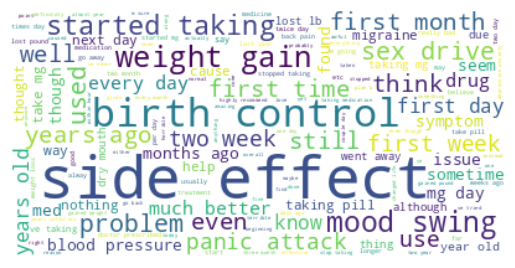

In [ ]:
words_combined = ' '.join(words)
word_cloud = WordCloud(background_color='white').generate(words_combined)
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## Most frequently occuring n-grams

In [ ]:
# Create a CountVectorizer to extract n-grams
n = 2
vectorizer = CountVectorizer(ngram_range=(n, n), stop_words='english')

# Fit and transform the cleaned reviews into n-grams
X = vectorizer.fit_transform([words_combined])

# Get the n-gram feature names
n_grams = vectorizer.get_feature_names_out()

# Get the frequency of each n-gram
n_gram_counts = X.toarray().sum(axis=0)

# Create a DataFrame to view the n-grams and their frequencies
n_gram_df = pd.DataFrame(list(zip(n_grams, n_gram_counts)), columns=['ngram', 'count'])

# Sort by count in descending order
n_gram_df = n_gram_df.sort_values(by='count', ascending=False)

# Display the top 10 most frequent n-grams
print(n_gram_df.head(10))

                  ngram  count
127238    birth control  19995
1477321     weight gain  10728
857841      mood swings  10078
1238623  started taking   9508
469893        feel like   8492
1169342       sex drive   7631
824251           mg day   6597
1524500       years ago   6579
476009        felt like   6101
1526746       years old   5505


## Review Counts and Lengths Analysis

In [ ]:
# Function to count words (handle multiple spaces)
def word_count(text):
  return len(re.findall(r'\b\w+\b', text))

# Function to count sentences
def sentence_count(text):
  return len(re.split(r'[.!?]+', text)) - 1

In [ ]:
# For train dataset
eda_dataset['word_count'] = eda_dataset['review'].apply(word_count)
eda_dataset['sentence_count'] = eda_dataset['review'].apply(sentence_count)

In [ ]:
# Summary statistics
review_stats= eda_dataset[['review_length', 'word_count', 'sentence_count']].describe()
print("Review Length Statistics:")
print(review_stats)

Review Length Statistics:
       review_length     word_count  sentence_count
count  184622.000000  184622.000000   184622.000000
mean       95.386238      97.574314        6.824187
std        38.566541      39.497527        3.238680
min        31.000000      26.000000        0.000000
25%        63.000000      64.000000        4.000000
50%        95.000000      97.000000        6.000000
75%       130.000000     133.000000        9.000000
max      1894.000000    1921.000000      100.000000


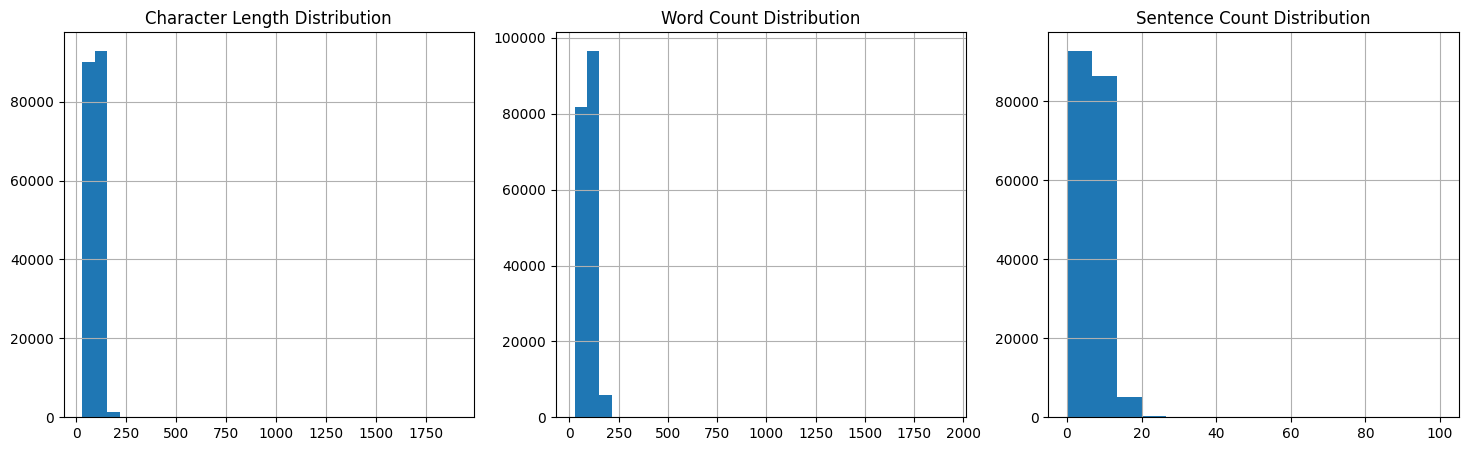

In [ ]:
# Visualization
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
eda_dataset['review_length'].hist(ax=ax[0], bins=30)
ax[0].set_title('Character Length Distribution')
eda_dataset['word_count'].hist(ax=ax[1], bins=30)
ax[1].set_title('Word Count Distribution')
eda_dataset['sentence_count'].hist(ax=ax[2], bins=15)
ax[2].set_title('Sentence Count Distribution')
plt.show()

## Missing Values Check and Handling

In [ ]:
# Check missing values
def check_missing(df, name):
  print(f"\nMissing values in {name}:")
  print(df.isnull().sum())

check_missing(eda_dataset, 'Dataset')


Missing values in Dataset:
Unnamed: 0        0
patient_id        0
drugName          0
condition         0
review            0
rating            0
date              0
usefulCount       0
review_length     0
word_count        0
sentence_count    0
dtype: int64


## Unique Ratings Analysis


Aggregated Dataset Rating Analysis:
Unique values: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
Value counts:
rating
1.0     23876
2.0      7948
3.0      7605
4.0      5862
5.0      9521
6.0      7419
7.0     11122
8.0     22086
9.0     32098
10.0    57085
Name: count, dtype: int64


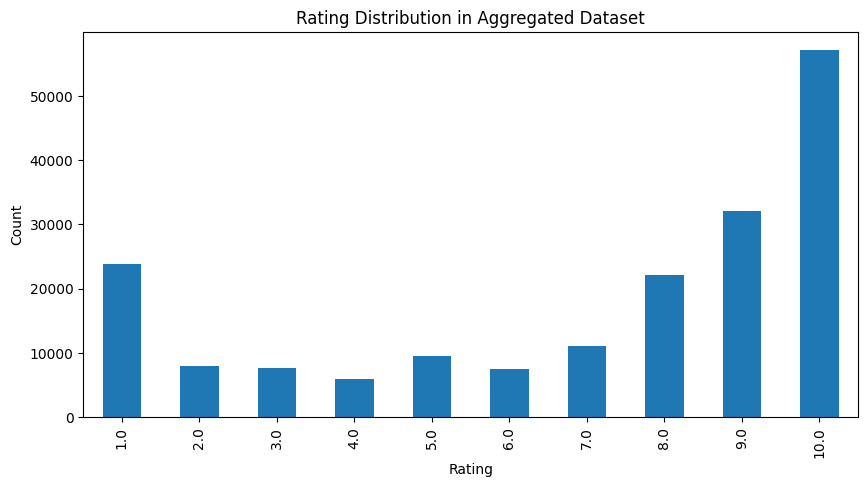

In [ ]:
# Check unique ratings
def analyse_ratings(df, name):
  print(f"\n{name} Rating Analysis:")
  print("Unique values:", sorted(df['rating'].unique()))
  print("Value counts:")
  print(df['rating'].value_counts().sort_index())

analyse_ratings(eda_dataset, 'Aggregated Dataset')

# Visualization
plt.figure(figsize=(10, 5))
eda_dataset['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Rating Distribution in Aggregated Dataset')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Class Balance and distribustion on Ratings

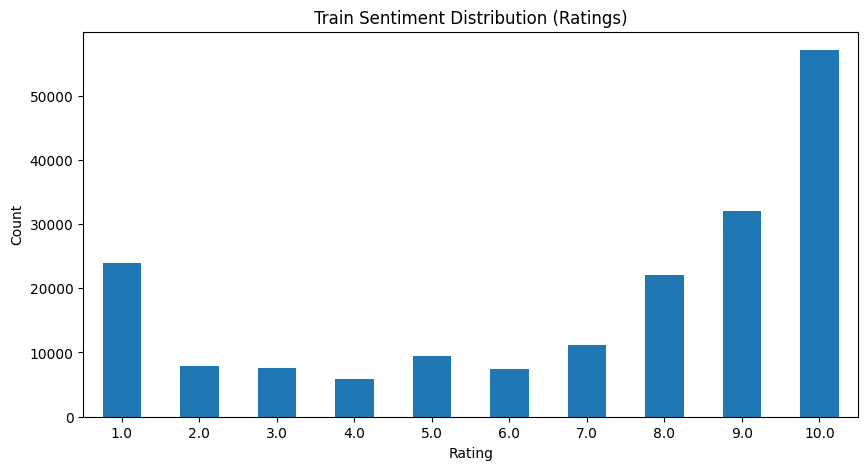

In [ ]:
# ------------------- 1. Sentiment Distribution (Class Balance) -------------------
plt.figure(figsize=(10, 5))
eda_dataset['rating'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Train Sentiment Distribution (Ratings)")
plt.xticks(rotation=0)
plt.show()

In [ ]:

# ------------------- 4. Categorical & Numerical Column Analysis -------------------

# Identify categorical and numerical columns
categorical_columns = eda_dataset.select_dtypes(include=['object']).columns.tolist()
numerical_columns = eda_dataset.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Summary of categorical columns
categorical_summary = eda_dataset[categorical_columns].nunique()
print("\nCategorical Column Summary:\n", categorical_summary)

# Summary of numerical columns
numerical_summary = eda_dataset[numerical_columns].describe()
print("\nNumerical Column Summary:\n", numerical_summary)


Categorical Column Summary:
 drugName       3247
condition       851
review       110903
date           3578
dtype: int64

Numerical Column Summary:
           Unnamed: 0     patient_id         rating    usefulCount  \
count  184622.000000  184622.000000  184622.000000  184622.000000   
mean     4867.017398  116089.516331       7.000401      28.457139   
std      2870.240959   66905.685539       3.243628      37.424977   
min         0.000000       0.000000       1.000000       0.000000   
25%      2386.000000   58654.250000       5.000000       6.000000   
50%      4815.000000  116097.500000       8.000000      16.000000   
75%      7308.000000  173490.750000      10.000000      37.000000   
max      9999.000000  232290.000000      10.000000    1291.000000   

       review_length     word_count  sentence_count  
count  184622.000000  184622.000000   184622.000000  
mean       95.386238      97.574314        6.824187  
std        38.566541      39.497527        3.238680  
min        

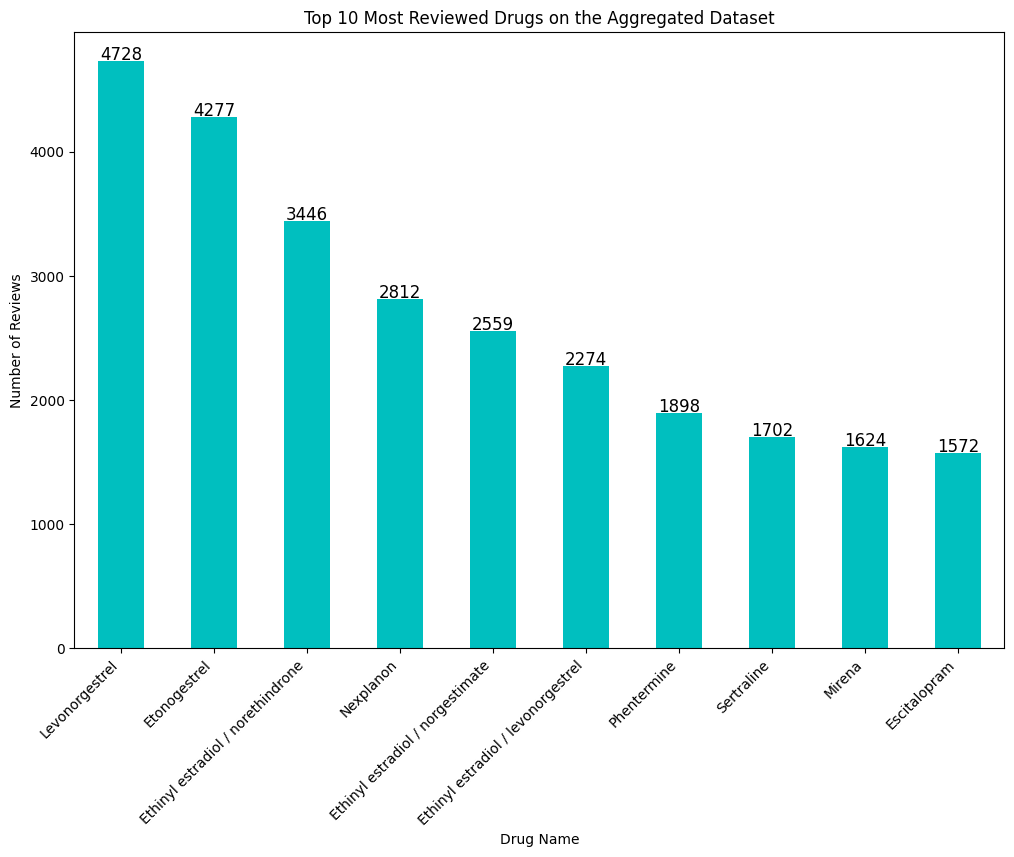


The most reviewed drug is 'Levonorgestrel' with 4728 reviews.


In [ ]:
# ------------------- 5. Most Reviewed Drug (Outliers) -------------------

# Find the most reviewed drug
most_reviewed_drug = eda_dataset['drugName'].value_counts().idxmax()
most_reviewed_count = eda_dataset['drugName'].value_counts().max()

# Get the top 10 most reviewed drugs
top_10_drugs = eda_dataset['drugName'].value_counts().head(10)

# Plot bar chart
plt.figure(figsize=(12, 8))
ax = top_10_drugs.plot(kind='bar', color='c')

# Annotate bars with their values
for i, v in enumerate(top_10_drugs.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=12)

plt.xlabel("Drug Name")
plt.ylabel("Number of Reviews")
plt.title("Top 10 Most Reviewed Drugs on the Aggregated Dataset")
plt.xticks(rotation=45, ha='right')
plt.show()

# Output most reviewed drug
print(f"\nThe most reviewed drug is '{most_reviewed_drug}' with {most_reviewed_count} reviews.")


# Model Training

In this section we are going to train three models:
1. Support Vector Machine
2. Long-Short Term Memory
3. Transformer

These models will be used for sentiment analysis, i.e. to classify the sentiment of a drug review. During training for each model, we will perform all the preprocessing necessary to prepare data for training that model.

## Transformer

To train the transformer, we are going to using the hugging face transformer library to load load a pre-trained model and fine-tune it on the data.

In [ ]:
# Install datasets module
!pip install datasets

# Install evaluate module
!pip install evaluate

In [ ]:
from huggingface_hub import login

# Login to Hugging Face Hub
login()

# Define model to be used
checkpoint = "akafesu/sentiment_analysis_assignment"

### Prepare the dataset for training using hugging face transformers

In this section, we are going to do the following:

1. Convert the dataset from pandas to hugging face dataset.
1. Tokenize the review column.
1. Drop unnecessary columns.
1. Rename the review column to text.
1. Rename the rating column to label.
1. Prepare a smaller dataset to experiment on before commiting on training the larger dataset.

In [ ]:
import numpy as np
from datasets import Dataset, DatasetDict
from transformers import DistilBertTokenizer

# Convert pandas dataframes to a hugging face dataset
transformer_dataset = DatasetDict({
    'train': Dataset.from_pandas(train),
    'test': Dataset.from_pandas(test),
    'val': Dataset.from_pandas(val),
})

# Define a tokenizer
tokenizer = DistilBertTokenizer.from_pretrained(checkpoint)

def get_rating_sentiment(rating):
  # Negative sentiment
  if rating < 5:
    return 0

  # Neutral sentiment
  if rating == 5:
    return 1

  # Positive sentiment
  if rating > 5:
    return 2

# Define a function to tokenize examples
def preprocess_dataset(example):
  """ Does the following:
  1. Encodes the review, and adds the input_ids,
  attention_mask, token_type_ids and labels to the
  dictionary returned.

  2. Creates a new column label, equal to rating - 1.
  """
  encoding = tokenizer(example['review'], truncation=True)
  convert_rating = np.vectorize(get_rating_sentiment)

  return {
      'input_ids': encoding.input_ids,
      'attention_mask': encoding.attention_mask,
      'label': convert_rating(example['rating'])
  }

# Tokenize the dataset
transformer_dataset = transformer_dataset.map(preprocess_dataset, batched=True)

# Remove unnecessary columns
transformer_dataset = transformer_dataset.remove_columns([
    'Unnamed: 0',
    'patient_id',
    'drugName',
    'condition',
    'date',
    'usefulCount',
    'review_length',
    'review',
    'rating'
])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.28k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Map:   0%|          | 0/110811 [00:00<?, ? examples/s]

Map:   0%|          | 0/46108 [00:00<?, ? examples/s]

Map:   0%|          | 0/27703 [00:00<?, ? examples/s]

In [ ]:
# Define smaller dataset for experimentation
transformer_mini_train_dataset = transformer_dataset['train'].shuffle(seed=42).select(range(1000))
transformer_mini_val_dataset = transformer_dataset['val'].shuffle(seed=42).select(range(200))

### Fine-tune the model

In this case, we are going to define the model and fine-tune it on the data. We are going to follow the following steps:

1. Define the training arguments
2. Define the base model
3. Define the trainer
4. Train!

In [ ]:
from transformers import DistilBertForSequenceClassification, TrainingArguments

# Define the training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=6,
    per_device_train_batch_size=48,
    per_device_eval_batch_size=48,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    save_strategy='epoch',
    eval_strategy='epoch',
    push_to_hub=True,
    hub_strategy="every_save",
    hub_model_id="akafesu/sentiment_analysis_assignment",
    load_best_model_at_end=True,
)

# Define the pre-trained model to use
model = DistilBertForSequenceClassification.from_pretrained(checkpoint, num_labels=3)

config.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

In [ ]:
from transformers import Trainer
import evaluate

def compute_metrics(eval_preds):
  # Extract the predictions and the actual values
  logits, labels = eval_preds

  # Create metric calculators
  accuracy_calculator = evaluate.load('accuracy')
  f1_calculator = evaluate.load('f1')

  # Convert logits to scalar labelsx
  predictions = logits.argmax(axis=-1)

  # Compute metrics
  accuracy = accuracy_calculator.compute(predictions=predictions, references=labels)["accuracy"]
  f1 = f1_calculator.compute(predictions=predictions, references=labels, average="macro")["f1"]

  return { 'accuracy': accuracy, 'f1': f1 }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=transformer_dataset['train'],
    eval_dataset=transformer_dataset['val'],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: anesu (anesu-african-leadership-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.182300,0.337302,0.893874,0.682873
2,0.134300,0.368809,0.889904,0.723837
3,0.127000,0.338399,0.911742,0.765507
4,0.070400,0.400742,0.915352,0.787542


# LSTM Model

This section will explore the use of Long Short term Memory in this taks to train a model that will capture the sentiments in the drug reviews

## Preprocessing steps done:
- The Unnamed: 0 column can be removed as it's redundant.
- rating converted into sentiment labels (e.g., positive, neutral, negative).
- Text cleaning(lowercase, remove special characters, and numbers etc).
- Tokernize and Pad.
- Convert text to sequence
- Convert Sentiment lables to numpy array
- Split

In [ ]:
# Create copy of the data sets
train_copy = train.copy()
test_copy = test.copy()
val_copy = val.copy()

In [ ]:
# Drop redundant index column if it exists
if 'Unnamed: 0' in train_copy.columns:
    train_copy.drop(columns=['Unnamed: 0'], inplace=True)
if 'Unnamed: 0' in test_copy.columns:
    test_copy.drop(columns=['Unnamed: 0'], inplace=True)
if 'Unnamed: 0' in val_copy.columns:
    val_copy.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
# Function to clean text data
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\b\d+\b', '', text)  # Remove standalone numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

# Apply text cleaning to reviews
train_copy['clean_review'] = train_copy['review'].apply(clean_text)
test_copy['clean_review'] = test_copy['review'].apply(clean_text)
val_copy['clean_review'] = val_copy['review'].apply(clean_text)

In [ ]:
# Convert ratings to sentiment labels: 1-4 (negative), 5 (neutral), 7-10 (positive)
def rating_to_sentiment(rating):
    if rating <5:
        return 0  # Negative
    elif rating == 5:
        return 1  # Neutral
    else:
        return 2  # Positive

train_copy['sentiment'] = train_copy['rating'].apply(rating_to_sentiment)
test_copy['sentiment'] = test_copy['rating'].apply(rating_to_sentiment)
val_copy['sentiment'] = val_copy['rating'].apply(rating_to_sentiment)

In [ ]:
# Tokenization and Padding
MAX_VOCAB_SIZE = 20000  # Maximum vocabulary size
MAX_SEQUENCE_LENGTH = 250  # Maximum review length

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_copy['clean_review'])

In [ ]:
# Convert text to sequences
train_sequences = tokenizer.texts_to_sequences(train_copy['clean_review'])
test_sequences = tokenizer.texts_to_sequences(test_copy['clean_review'])
validation_sequences = tokenizer.texts_to_sequences(val_copy['clean_review'])


# Pad sequences to ensure uniform length
train_padded = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
validation_padded = pad_sequences(validation_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

In [ ]:
# Convert sentiment labels to numpy arrays
train_labels = np.array(train_copy['sentiment'])
test_labels = np.array(test_copy['sentiment'])
validation_labels = np.array(val_copy['sentiment'])

In [ ]:
# Split training data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(train_padded, train_labels, test_size=0.1, random_state=42)

In [ ]:
# Define LSTM Model with Explicit Input Shape
EMBEDDING_DIM = 128
LSTM_UNITS = 64

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    tf.keras.layers.LSTM(LSTM_UNITS, return_sequences=True),
    tf.keras.layers.LSTM(LSTM_UNITS),
    tf.keras.layers.Dense(3, activation='softmax'),
])

# Force Model to Build (Fixing ? in Output Shape)
model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))
model.summary()

# Compile the Model
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

# Train the Model
EPOCHS = 25
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)              │ (None, 250, 128)            │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_20 (LSTM)                       │ (None, 250, 64)             │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_21 (LSTM)                       │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,642,627 (10.08 MB)

 Trainable params: 2,642,627 (10.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
3117/3117 ━━━━━━━━━━━━━━━━━━━━ 944s 301ms/step - accuracy: 0.7041 - loss: 0.7461 - val_accuracy: 0.7123 - val_loss: 0.7341
Epoch 2/25
3117/3117 ━━━━━━━━━━━━━━━━━━━━ 972s 298ms/step - accuracy: 0.7030 - loss: 0.7469 - val_accuracy: 0.7123 - val_loss: 0.7370
Epoch 3/25
3117/3117 ━━━━━━━━━━━━━━━━━━━━ 928s 298ms/step - accuracy: 0.7042 - loss: 0.7458 - val_accuracy: 0.7125 - val_loss: 0.7341
Epoch 4/25
3117/3117 ━━━━━━━━━━━━━━━━━━━━ 988s 300ms/step - accuracy: 0.7023 - loss: 0.7469 - val_accuracy: 0.7126 - val_loss: 0.7349
Epoch 5/25
3117/3117 ━━━━━━━━━━━━━━━━━━━━ 931s 299ms/step - accuracy: 0.7020 - loss: 0.7506 - val_accuracy: 0.7126 - val_loss: 0.7340
Epoch 6/25
3117/3117 ━━━━━━━━━━━━━━━━━━━━ 980s 298ms/step - accuracy: 0.7061 - loss: 0.7427 - val_accuracy: 0.7125 - val_loss: 0.7343
Epoch 7/25
3117/3117 ━━━━━━━━━━━━━━━━━━━━ 974s 295ms/step - accuracy: 0.7020 - loss: 0.7459 - val_accuracy: 0.7125 - val_loss: 0.7336
Epoch 8/25
3117/3117 ━━━━━━━━━━━━━━━━━━━━ 916s 294ms/step - ac

In [ ]:
# Save the trained model and tokenizer
model.save("sentiment_lstm_model.h5")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Model and tokenizer saved successfully!")

Model and tokenizer saved successfully!


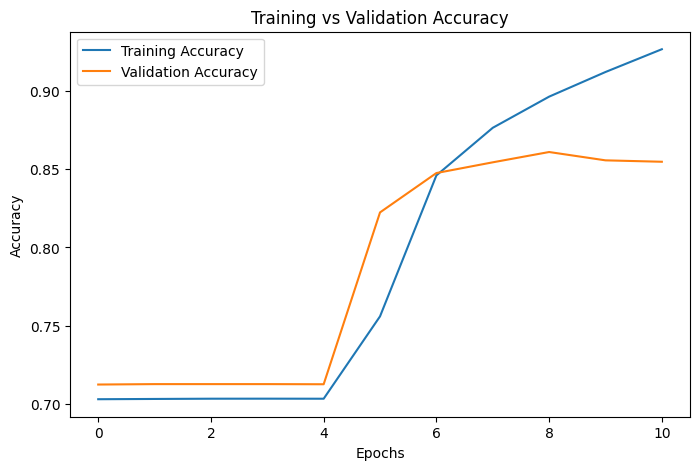

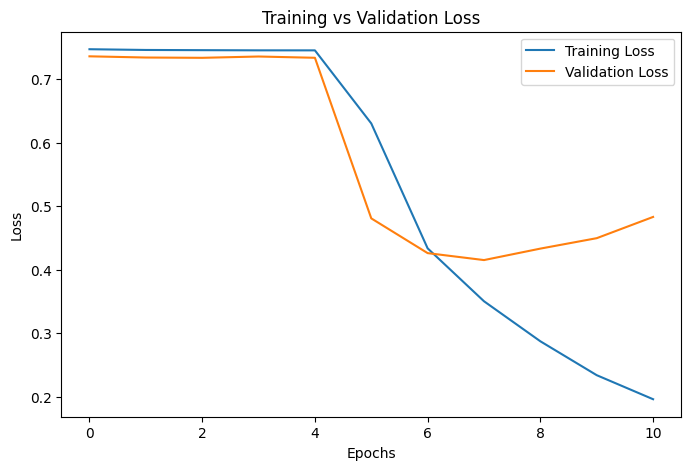

In [ ]:
import matplotlib.pyplot as plt

# Extract accuracy and loss values
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot Accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


In [ ]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(test_padded, test_labels)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

1441/1441 ━━━━━━━━━━━━━━━━━━━━ 71s 49ms/step - accuracy: 0.8505 - loss: 0.4299
Test Accuracy: 0.8500
Test Loss: 0.4325


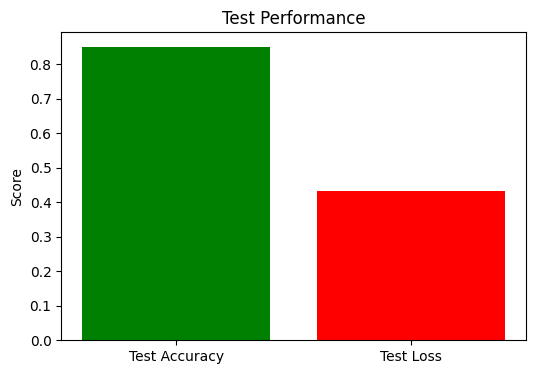

In [ ]:
# Bar Chart for Test Accuracy & Loss
plt.figure(figsize=(6, 4))
plt.bar(["Test Accuracy", "Test Loss"], [test_accuracy, test_loss], color=['green', 'red'])
plt.title("Test Performance")
plt.ylabel("Score")
plt.show()


## Making predictions with the model

In [ ]:
# Load the trained model
model = tf.keras.models.load_model("sentiment_lstm_model.h5")

# Load the tokenizer
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# Define max sequence length (must match training config)
MAX_SEQUENCE_LENGTH = 250

# Sentiment Mapping
sentiment_labels = {0: "Negative", 1: "Neutral", 2: "Positive"}

def clean_text(text):
    """Preprocess the input text (same as used during training)."""
    import re
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\b\d+\b', '', text)  # Remove numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

def rating_to_sentiment(rating):
    """Converts user-entered rating to sentiment class (same as during training)."""
    rating = float(rating)  # Ensure it's a float
    if rating < 5:
        return 0  # Negative
    elif rating == 5:
        return 1  # Neutral
    else:
        return 2  # Positive

def predict_sentiment(review, rating):
    """Predicts sentiment using both the review and rating."""
    cleaned_review = clean_text(review)  # Preprocess review
    sequence = tokenizer.texts_to_sequences([cleaned_review])  # Convert to sequence
    padded_sequence = pad_sequences(sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')  # Pad

    model_prediction = model.predict(padded_sequence)  # Model prediction
    predicted_class = np.argmax(model_prediction)  # Get highest probability class
    model_sentiment = sentiment_labels[predicted_class]  # Convert class to label
    model_confidence = model_prediction[0][predicted_class]  # Get confidence

    # Convert user rating to sentiment
    rating_sentiment_class = rating_to_sentiment(rating)
    rating_sentiment = sentiment_labels[rating_sentiment_class]

    # Display results
    print("\n🔹 Predictions:")
    print(f" This is a  → {model_sentiment} review with a confidence of {model_confidence:.2f}")
    print(f" Rating based sentiment  → {rating_sentiment}")

    if predicted_class == rating_sentiment_class:
        print("✅ The model's prediction matches the rating-based sentiment!")
    else:
        print("⚠️ The model's prediction differs from the rating-based sentiment.")

# User Input: Review
review_text = input("💬 Enter your drug review: ")

# User Input: Rating
while True:
    try:
        user_rating = float(input("⭐ Enter your rating (1-10): "))
        if 1 <= user_rating <= 10:
            break
        else:
            print("❌ Please enter a rating between 1 and 10.")
    except ValueError:
        print("❌ Invalid input. Please enter a number between 1 and 10.")

# Make Prediction
predict_sentiment(review_text, user_rating)

💬 Enter your drug review: I don't know how I feel about this drug
⭐ Enter your rating (1-10): 5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step

🔹 Predictions:
 This is a  → Negative review with a confidence of 0.42
 Rating based sentiment  → Neutral
⚠️ The model's prediction differs from the rating-based sentiment.


## **Multinomial Naive Bayes**

We are using the Multinomial Naive Bayes (MultinomialNB) classifier for sentiment analysis in the drug review to classify them into three categories positive, neutral, and negative.

In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

### DATA PREPARATION

In [ ]:
# Copy datasets to new memory
trad_dataset_train = train.copy()
trad_dataset_test = test.copy()
trad_dataset_val = val.copy()

In [ ]:
def rating_to_sentiment(rating):
    if pd.isnull(rating):
        return 'neutral'
    if rating <= 4:
        return 'negative'
    elif 5 <= rating <= 6:
        return 'neutral'
    else:
        return 'positive'

# Apply to all datasets
for df in [trad_dataset_train, trad_dataset_test, trad_dataset_val]:
    df['sentiment'] = df['rating'].apply(rating_to_sentiment)

In [ ]:
# Create feature and target variables
X_train = trad_dataset_train['review']
y_train = trad_dataset_train['sentiment']
X_test = trad_dataset_test['review']
y_test = trad_dataset_test['sentiment']
X_val = trad_dataset_val['review']
y_val = trad_dataset_val['sentiment']

### TEXT PROCESSING PIPELINE

In [ ]:
# Custom preprocessing function
def enhanced_cleaner(text):
    # Handle missing values
    text = text if isinstance(text, str) else ''
    # Preserve contractions and currency symbols
    text = re.sub(r"[^a-zA-Z0-9\$\'’]", " ", text)
    # Remove extra spaces
    return re.sub(r"\s+", " ", text).strip()


In [ ]:
# Create enhanced pipeline
pipeline = Pipeline([
    ('vectorizer', CountVectorizer(
        preprocessor=enhanced_cleaner,
        lowercase=True,
        stop_words='english',
        ngram_range=(1, 3),  # Include trigrams
        max_features=8000,    # Increased feature space
        min_df=5,            # Ignore rare terms
        max_df=0.7           # Ignore overly common terms
    )),
    ('tfidf', TfidfTransformer()),  # Add TF-IDF weighting
    ('classifier', MultinomialNB(
        alpha=0.5,           # Tuned smoothing
        fit_prior=False      # Uniform prior for class balance
    ))
])


### MODEL TRAINING & EVALUATION

In [ ]:
# Train model
pipeline.fit(X_train, y_train)

# Cross-validation
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.2f}")

Cross-Validation Scores: [0.6654785  0.66920856 0.66690732 0.66320729 0.66997563]
Mean CV Accuracy: 0.67



Test Set Classification Report:
              precision    recall  f1-score   support

    negative       0.63      0.64      0.64     11445
     neutral       0.19      0.45      0.27      4254
    positive       0.88      0.70      0.78     30409

    accuracy                           0.67     46108
   macro avg       0.57      0.60      0.56     46108
weighted avg       0.75      0.67      0.70     46108



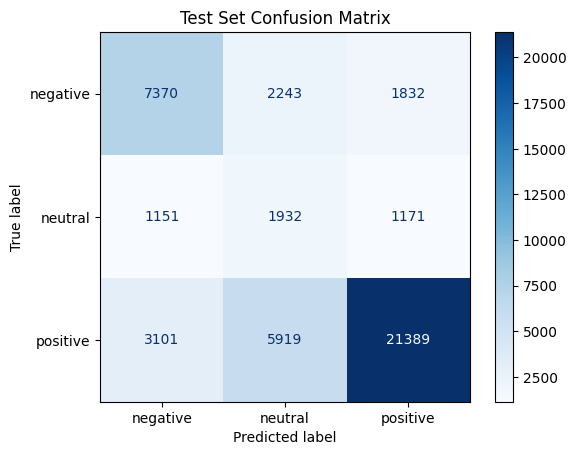

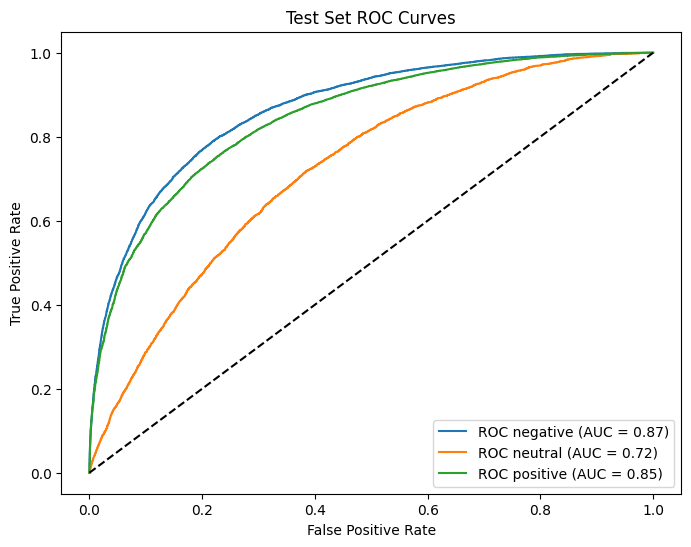


Validation Set Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.64      0.64      6743
     neutral       0.19      0.46      0.27      2616
    positive       0.88      0.71      0.78     18344

    accuracy                           0.67     27703
   macro avg       0.57      0.60      0.56     27703
weighted avg       0.75      0.67      0.70     27703



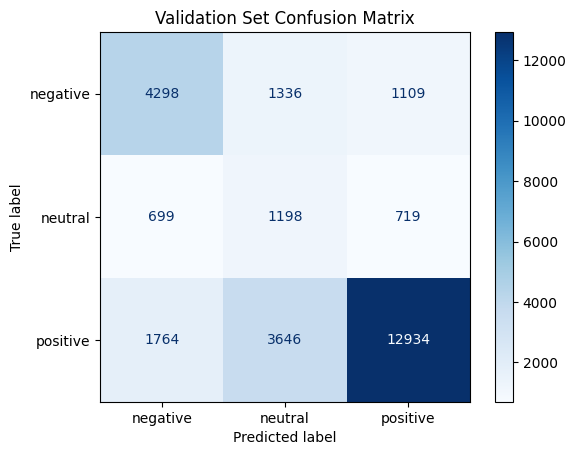

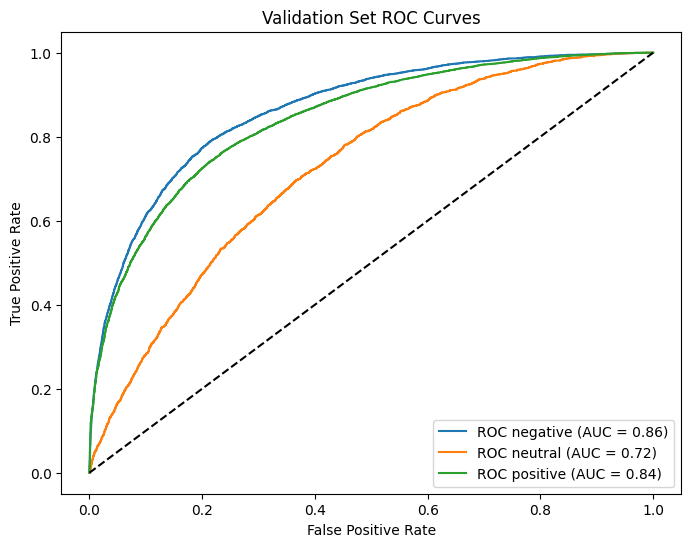

In [ ]:
# Generate predictions
def evaluate_model(X, y, dataset_name):
    y_pred = pipeline.predict(X)
    y_proba = pipeline.predict_proba(X)

    print(f"\n{dataset_name} Classification Report:")
    print(classification_report(y, y_pred, target_names=['negative', 'neutral', 'positive']))

    # Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=pipeline.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{dataset_name} Confusion Matrix")
    plt.show()

    # ROC Curve (OvR for multiclass)
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    n_classes = len(le.classes_)

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_encoded, y_proba[:, i], pos_label=i)
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f'ROC {le.classes_[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{dataset_name} ROC Curves')
    plt.legend()
    plt.show()

# Evaluate on all datasets
evaluate_model(X_test, y_test, "Test Set")
evaluate_model(X_val, y_val, "Validation Set")

### FEATURE ANALYSIS

In [ ]:
# Get feature names
feature_names = pipeline.named_steps['vectorizer'].get_feature_names_out()

# Get classifier log probabilities (instead of coef_)
coefs = pipeline.named_steps['classifier'].feature_log_prob_

# Create coefficient DataFrame (using exponentiation to get probabilities)
coef_df = pd.DataFrame(np.exp(coefs).T, index=feature_names,
                       columns=pipeline.classes_)

# Show top features for each class
print("\nTop Predictive Features:")
for class_name in coef_df.columns:
    print(f"\n{class_name.upper()}:")
    print(coef_df[class_name].sort_values(ascending=False).head(10))


Top Predictive Features:

NEGATIVE:
taking     0.003789
pain       0.003717
day        0.003690
months     0.003683
ve         0.003546
like       0.003500
pill       0.003358
days       0.003297
started    0.003247
took       0.003117
Name: negative, dtype: float64

NEUTRAL:
day        0.003950
taking     0.003872
ve         0.003770
months     0.003559
started    0.003298
pain       0.003297
days       0.003215
effects    0.003184
just       0.003104
like       0.003093
Name: neutral, dtype: float64

POSITIVE:
years      0.004008
day        0.004000
pain       0.003732
ve         0.003580
effects    0.003524
taking     0.003502
started    0.002965
time       0.002958
days       0.002957
just       0.002945
Name: positive, dtype: float64
